# Conclusion: Best Practices and Future Trends in Options Pricing

## Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

from scipy.stats import norm
from gymnasium import spaces
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense
from stable_baselines3 import A2C, PPO
from stable_baselines3.common.vec_env import DummyVecEnv

## Recap of Key Concepts and Best Practices

In [2]:
# Loading mb_tickerdf12302025 2025-12-30 17-24-53-423976
# Define the file path
file_path = "mb_tickerdf12302025 2025-12-30 17-24-53-423976.csv"

# Load the file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2020-12-31,130.520487,131.162969,128.223139,129.167389,99116600,0.0,0.0
1,2021-01-04,129.975370,130.062977,123.394829,125.974480,143301900,0.0,0.0
2,2021-01-05,125.468261,128.242606,125.020466,127.531975,97664900,0.0,0.0
3,2021-01-06,124.329352,127.570950,123.024922,123.239082,155088000,0.0,0.0
4,2021-01-07,124.952354,128.135547,124.465627,127.444389,109578200,0.0,0.0


In [3]:
# Get Data
data = df.copy()

# Compute daily returns
data['Returns'] = data['Close'].pct_change()

# Assume an option's delta is 0.5
delta = 0.5

# Calculate required hedge for each day
data['Hedge'] = -delta * data['Returns']

# Compute cumulative returns of the hedge
data['Cumulative Hedge Returns'] = np.cumprod(1 + data['Hedge'].fillna(0))

data[['Close', 'Hedge', 'Cumulative Hedge Returns']]

,Close,Hedge,Cumulative Hedge Returns
0,129.167389,NaN,1.000000
1,125.974480,0.012360,1.012360
2,127.531975,-0.006182,1.006101
3,123.239082,0.016831,1.023035
4,127.444389,-0.017062,1.005580
...,...,...,...
1250,272.359985,-0.002565,0.595768
1251,273.809998,-0.002662,0.594182
1252,273.399994,0.000749,0.594627
1253,273.760010,-0.000658,0.594235


## Machine Learning and AI in Options Valuation

### Predictive analytics

In [4]:
# Using current-day OHLC data to predict the next day's closing price
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# Feature columns: using Open, High, Low, Close as features
features = df[['Open', 'High', 'Low', 'Close']]
target = df['Target']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

Mean Squared Error: 9.1944
Root Mean Squared Error: 3.0322


### Neural Networks for Nonlinear Relationships in Options Pricing

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1461 - val_loss: 0.1031
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0901 - val_loss: 0.0998
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0866 - val_loss: 0.0985
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0848 - val_loss: 0.0942
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0847 - val_loss: 0.0933
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0831 - val_loss: 0.0939
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0849 - val_loss: 0.0915
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0822 - val_loss: 0.0909
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0827 - val_loss: 0.0921
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0822 - val_loss: 0.0907
Epoch 11/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0817 - val_loss: 0.0909
Epoch 12/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

Text(0, 0.5, 'Option Price')

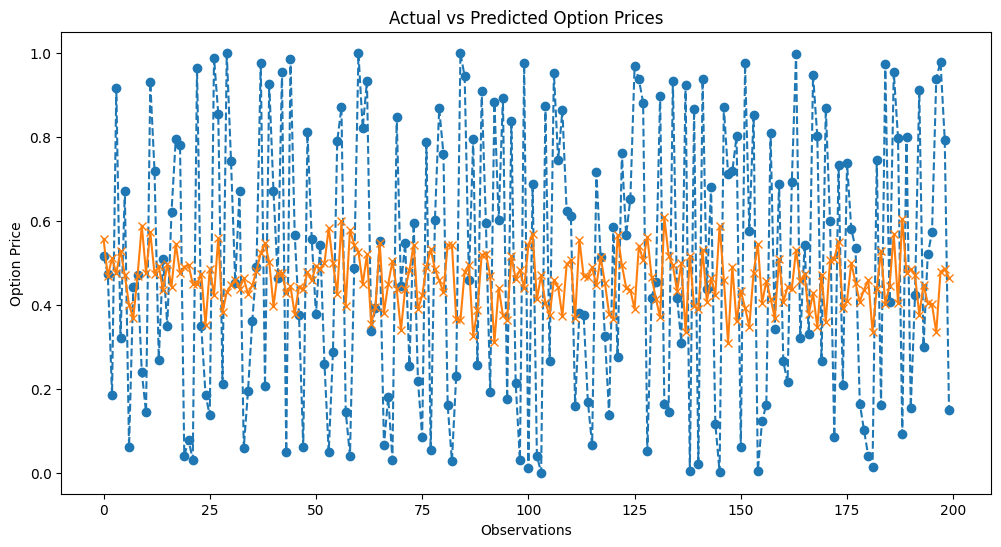

In [5]:
# Generating synthetic data for option pricing (e.g., Black-Scholes model outputs)
X = np.random.rand(1000, 3)  # Features: [Underlying Price, Volatility, Time to Maturity]
y = np.random.rand(1000, 1)  # Option Prices

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the Neural Network model
model = Sequential()

# Add an Input layer as the first layer
model.add(Input(shape=(3,)))

# Add subsequent layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compiling the model
model.compile(optimizer='adam', loss='mse')

# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=10, validation_split=0.2)

# Predicting option prices
predictions = model.predict(X_test)

# Plotting the actual vs predicted option prices
plt.figure(figsize=(12, 6))

# Plot the actual option prices
plt.plot(y_test, label="Actual Option Price", linestyle='--', marker='o')

# Plot the predicted option prices
plt.plot(predictions, label="Predicted Option Price", linestyle='-', marker='x')

# Adding title and labels
plt.title("Actual vs Predicted Option Prices")
plt.xlabel("Observations")
plt.ylabel("Option Price")


### Neural Networks for Time Series Forecasting in Options Pricing

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1491 - val_loss: 0.0826
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0922 - val_loss: 0.0814
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0896 - val_loss: 0.0821
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0888 - val_loss: 0.0836
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0882 - val_loss: 0.0845
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0885 - val_loss: 0.0850
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0880 - val_loss: 0.0818
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0875 - val_loss: 0.0794
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0874 - val_loss: 0.0806
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0867 - val_loss: 0.0809
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0867 - val_loss: 0.0813
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0867 -

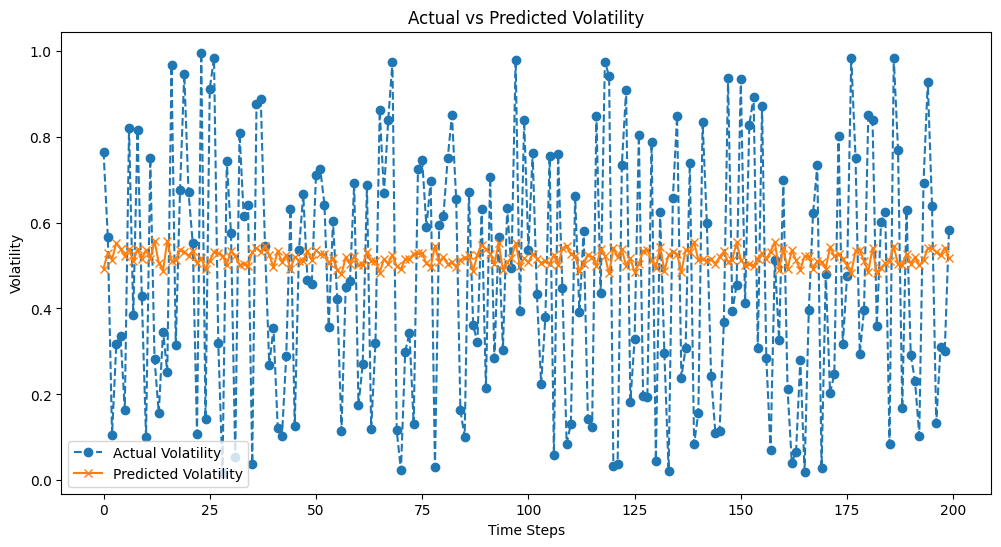

In [6]:
# Assuming X is the time series data for historical volatility
X = np.random.rand(1000, 10, 1)  # Shape: [Samples, Time Steps, Features]
y = np.random.rand(1000, 1)  # Future volatility

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the LSTM model
model = Sequential()

# Add an Input layer for LSTM
model.add(Input(shape=(10, 1)))

# Add LSTM and Dense layers
model.add(LSTM(50))
model.add(Dense(1))

# Compiling the model
model.compile(optimizer='adam', loss='mse')

# Training the model
model.fit(X_train, y_train, epochs=50, batch_size=20, validation_split=0.2)

# Predicting future volatility
predictions = model.predict(X_test)

# Plotting the actual vs predicted volatility
plt.figure(figsize=(12, 6))

# Plot the actual volatility values
plt.plot(y_test, label="Actual Volatility", linestyle='--', marker='o')

# Plot the predicted volatility values
plt.plot(predictions, label="Predicted Volatility", linestyle='-', marker='x')

# Adding title and labels
plt.title("Actual vs Predicted Volatility")
plt.xlabel("Time Steps")
plt.ylabel("Volatility")
plt.legend()
plt.show()

### Reinforcement Learning for Dynamic Hedging

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 995  |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 903           |
|    iterations           | 2             |
|    time_elapsed         | 2             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00010779442 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.42         |
|    explained_variance   | -0.000602     |
|    learning_rate        | 0.0001        |
|    loss                 | 2.76e+03      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000113     |
|    std                  | 1             |
|    value_loss          

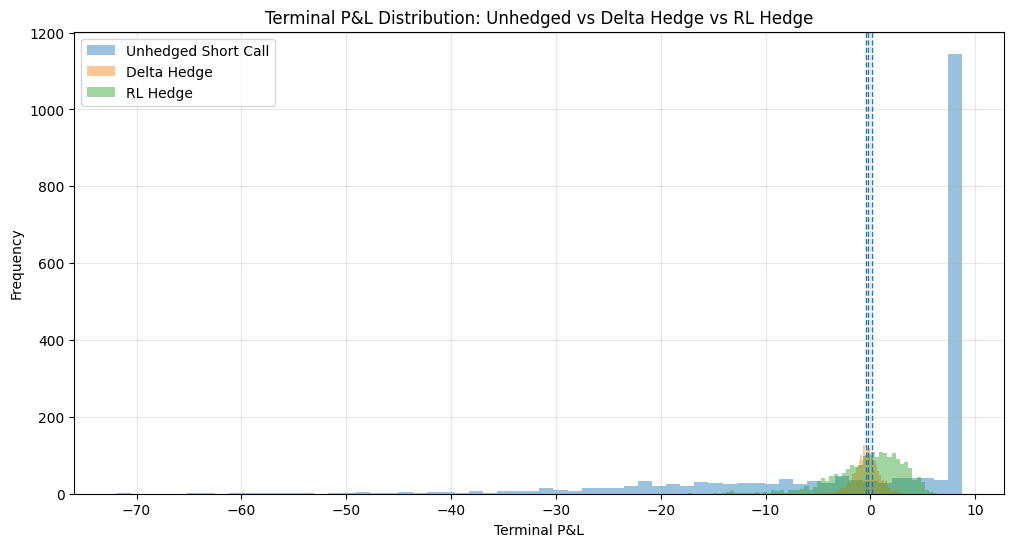

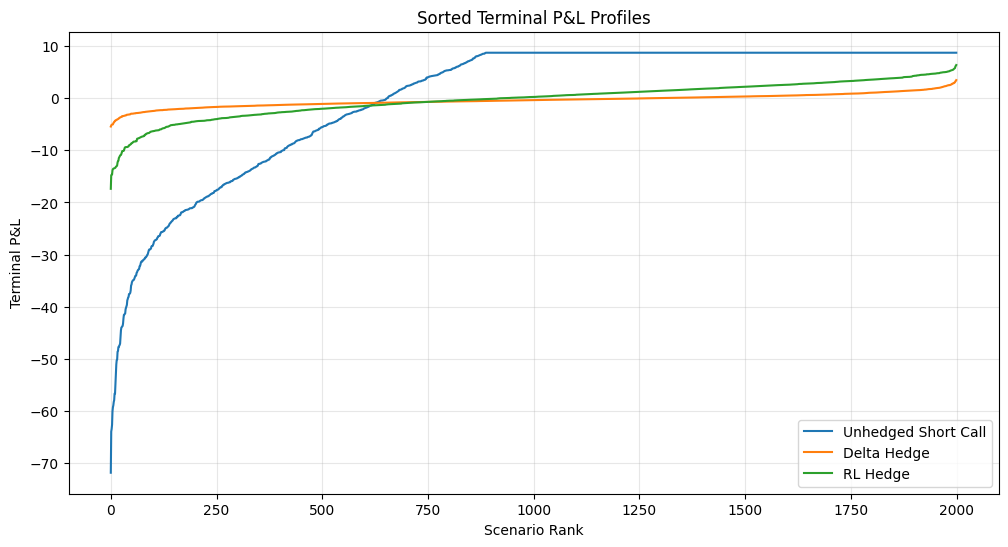

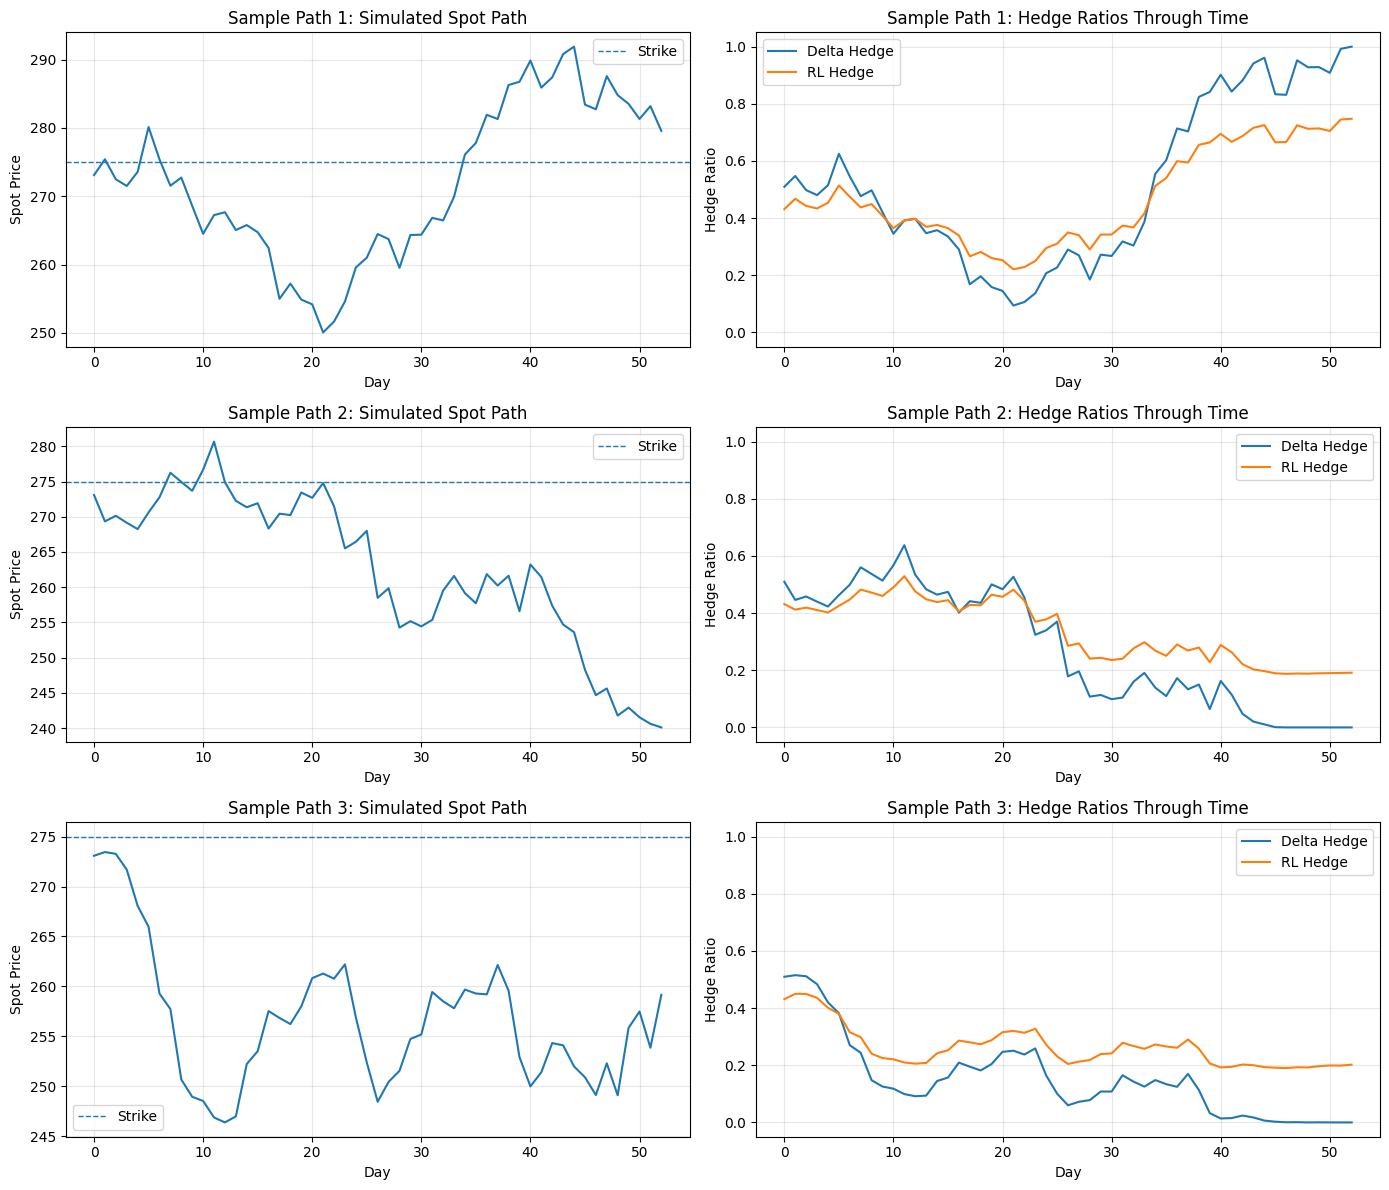

In [7]:
# ============================================================
# RL Dynamic Hedging with Market-Based Inputs
#
# Source files used earlier in the book:
# - mb_all_options_data12302025
# - mb_tickerdf12302025
# - mb_US_T_12292025
#
# Selected contract from the market snapshot:
# AAPL 2026-02-20 275 Call
# ============================================================

# ============================================================
# 1. Contract and experiment inputs
# ============================================================

# Extracted from the market snapshot / market files
S0 = 273.08
K = 275.00
T_days = 52
T = T_days / 365.0
r = 0.03686
sigma_iv = 0.23359
option_mid = 8.75

# Hedging / simulation setup
n_steps = T_days                  # daily rebalancing
dt = 1 / 365
n_train_paths = 4000
n_test_paths = 2000
transaction_cost_bps = 5          # 5 bps per dollar traded
mu = 0.00                         # simple neutral drift
seed_train = 42
seed_test = 123


# ============================================================
# 2. Black-Scholes helper functions
# ============================================================

def mb_bs_call_price(S, K, T, r, sigma):
    """
    Black-Scholes European call price.
    Supports scalar or numpy array S.
    """
    S = np.asarray(S, dtype=float)
    S = np.maximum(S, 1e-12)

    if T <= 0:
        return np.maximum(S - K, 0.0)

    sigma = max(float(sigma), 1e-12)
    sqrtT = np.sqrt(T)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT

    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def mb_bs_call_delta(S, K, T, r, sigma):
    """
    Black-Scholes European call delta.
    Supports scalar or numpy array S.
    """
    S = np.asarray(S, dtype=float)
    S = np.maximum(S, 1e-12)

    if T <= 0:
        return np.where(S > K, 1.0, 0.0)

    sigma = max(float(sigma), 1e-12)
    sqrtT = np.sqrt(T)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    return norm.cdf(d1)


# ============================================================
# 3. Spot path simulation
# ============================================================

def simulate_gbm_paths(S0, mu, sigma, dt, n_steps, n_paths, seed=42):
    """
    Simulate GBM paths.
    Returns array of shape (n_paths, n_steps + 1).
    """
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, n_steps))

    paths = np.zeros((n_paths, n_steps + 1), dtype=float)
    paths[:, 0] = S0

    for t in range(1, n_steps + 1):
        paths[:, t] = paths[:, t - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t - 1]
        )

    return paths


def simulate_one_gbm_path(S0, mu, sigma, dt, n_steps, seed=123):
    """
    Simulate one GBM path.
    """
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_steps)

    path = np.zeros(n_steps + 1, dtype=float)
    path[0] = S0

    for t in range(1, n_steps + 1):
        path[t] = path[t - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t - 1]
        )

    return path


# ============================================================
# 4. Benchmarks
# ============================================================

def run_unhedged_short_call(paths, K, r, sigma, dt, option_premium=None):
    """
    P&L of a short call held to maturity with no hedge.
    """
    n_steps = paths.shape[1] - 1
    T0 = n_steps * dt

    if option_premium is None:
        premium = mb_bs_call_price(paths[:, 0], K, T0, r, sigma)
    else:
        premium = np.full(paths.shape[0], option_premium, dtype=float)

    payoff = np.maximum(paths[:, -1] - K, 0.0)
    pnl = premium - payoff
    return pnl


def run_delta_hedge(paths, K, r, sigma, dt, transaction_cost_bps, option_premium=None):
    """
    Correct discrete delta hedge using cash + stock inventory framework.
    """
    n_paths = paths.shape[0]
    n_steps = paths.shape[1] - 1
    T0 = n_steps * dt

    if option_premium is None:
        cash = mb_bs_call_price(paths[:, 0], K, T0, r, sigma).astype(float)
    else:
        cash = np.full(n_paths, option_premium, dtype=float)

    hedge_pos = np.zeros(n_paths, dtype=float)

    for t in range(n_steps):
        tau_t = (n_steps - t) * dt
        S_t = paths[:, t]

        target_delta = mb_bs_call_delta(S_t, K, tau_t, r, sigma)

        trade = target_delta - hedge_pos
        tc = np.abs(trade) * S_t * (transaction_cost_bps / 10000.0)

        # Rebalance hedge
        cash -= trade * S_t
        cash -= tc
        hedge_pos = target_delta

    # Liquidate hedge at maturity
    S_T = paths[:, -1]
    close_tc = np.abs(hedge_pos) * S_T * (transaction_cost_bps / 10000.0)
    cash += hedge_pos * S_T
    cash -= close_tc

    # Pay short call payoff
    payoff = np.maximum(S_T - K, 0.0)
    pnl = cash - payoff

    return pnl


# ============================================================
# 5. RL hedging environment
# ============================================================

class HedgingEnv(gym.Env):
    """
    RL environment for short-1-call dynamic hedging.

    Action:
        Continuous target hedge ratio in [0, 1]

    State:
        [spot_norm, moneyness, tau, bs_delta, current_hedge, recent_return]
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        S0,
        K,
        r,
        sigma,
        option_premium,
        n_steps,
        dt,
        transaction_cost_bps,
        mu=0.0,
        seed=42
    ):
        super().__init__()

        self.S0 = float(S0)
        self.K = float(K)
        self.r = float(r)
        self.sigma = float(sigma)
        self.option_premium = float(option_premium)
        self.n_steps = int(n_steps)
        self.dt = float(dt)
        self.transaction_cost_bps = float(transaction_cost_bps)
        self.mu = float(mu)

        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Box(
            low=np.array([0.0], dtype=np.float32),
            high=np.array([1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, 0.0, 0.0, -1.0], dtype=np.float32),
            high=np.array([10.0, 10.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.path = None
        self.t = None
        self.hedge_pos = None
        self.cash = None

    def _simulate_one_path(self):
        Z = self.rng.standard_normal(self.n_steps)
        path = np.zeros(self.n_steps + 1, dtype=float)
        path[0] = self.S0

        for t in range(1, self.n_steps + 1):
            path[t] = path[t - 1] * np.exp(
                (self.mu - 0.5 * self.sigma**2) * self.dt
                + self.sigma * np.sqrt(self.dt) * Z[t - 1]
            )
        return path

    def _get_state(self):
        S_t = self.path[self.t]
        tau_t = max((self.n_steps - self.t) * self.dt, 0.0)

        if tau_t > 0:
            delta_t = float(mb_bs_call_delta(S_t, self.K, tau_t, self.r, self.sigma))
        else:
            delta_t = 1.0 if S_t > self.K else 0.0

        if self.t == 0:
            recent_ret = 0.0
        else:
            recent_ret = self.path[self.t] / self.path[self.t - 1] - 1.0

        state = np.array([
            S_t / self.S0,
            S_t / self.K,
            tau_t / (self.n_steps * self.dt),
            delta_t,
            self.hedge_pos,
            recent_ret
        ], dtype=np.float32)

        return state

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.path = self._simulate_one_path()
        self.t = 0
        self.hedge_pos = 0.0
        self.cash = self.option_premium

        return self._get_state(), {}

    def step(self, action):
        target_hedge = float(np.clip(action[0], 0.0, 1.0))

        S_t = self.path[self.t]
        S_next = self.path[self.t + 1]

        tau_t = (self.n_steps - self.t) * self.dt
        tau_next = max((self.n_steps - (self.t + 1)) * self.dt, 0.0)

        option_value_t = float(mb_bs_call_price(S_t, self.K, tau_t, self.r, self.sigma))
        option_value_next = float(mb_bs_call_price(S_next, self.K, tau_next, self.r, self.sigma))

        # Rebalance hedge
        trade = target_hedge - self.hedge_pos
        tc = abs(trade) * S_t * (self.transaction_cost_bps / 10000.0)

        self.cash -= trade * S_t
        self.cash -= tc
        self.hedge_pos = target_hedge

        # Mark-to-market portfolio
        portfolio_t = self.cash + self.hedge_pos * S_t - option_value_t
        portfolio_next = self.cash + self.hedge_pos * S_next - option_value_next

        step_pnl = portfolio_next - portfolio_t

        # Penalize unstable hedge outcomes and trading costs
        reward = -(step_pnl ** 2) - 0.1 * tc

        self.t += 1
        terminated = self.t == self.n_steps
        truncated = False
        info = {}

        if terminated:
            S_T = self.path[self.t]

            # Liquidate hedge
            close_tc = abs(self.hedge_pos) * S_T * (self.transaction_cost_bps / 10000.0)
            self.cash += self.hedge_pos * S_T
            self.cash -= close_tc
            self.hedge_pos = 0.0

            # Short call payoff
            payoff = max(S_T - self.K, 0.0)
            self.cash -= payoff

            final_pnl = self.cash
            info["final_pnl"] = final_pnl

            # Terminal penalty
            reward += -(final_pnl ** 2)

        return self._get_state(), reward, terminated, truncated, info


# ============================================================
# 6. Train PPO agent
# ============================================================

def make_env():
    return HedgingEnv(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma_iv,
        option_premium=option_mid,
        n_steps=n_steps,
        dt=dt,
        transaction_cost_bps=transaction_cost_bps,
        mu=mu,
        seed=seed_train
    )

vec_env = DummyVecEnv([make_env])

model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    verbose=1,
    learning_rate=1e-4,
    n_steps=1024,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.001
)

model.learn(total_timesteps=150000)


# ============================================================
# 7. Evaluate RL hedge
# ============================================================

def evaluate_rl_agent(model, n_eval_episodes=1000, seed=999):
    env = HedgingEnv(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma_iv,
        option_premium=option_mid,
        n_steps=n_steps,
        dt=dt,
        transaction_cost_bps=transaction_cost_bps,
        mu=mu,
        seed=seed
    )

    final_pnls = []

    for _ in range(n_eval_episodes):
        obs, _ = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        final_pnls.append(info["final_pnl"])

    return np.array(final_pnls, dtype=float)


# ============================================================
# 8. Generate test paths and benchmark results
# ============================================================

test_paths = simulate_gbm_paths(
    S0=S0,
    mu=mu,
    sigma=sigma_iv,
    dt=dt,
    n_steps=n_steps,
    n_paths=n_test_paths,
    seed=seed_test
)

pnl_unhedged = run_unhedged_short_call(
    paths=test_paths,
    K=K,
    r=r,
    sigma=sigma_iv,
    dt=dt,
    option_premium=option_mid
)

pnl_delta = run_delta_hedge(
    paths=test_paths,
    K=K,
    r=r,
    sigma=sigma_iv,
    dt=dt,
    transaction_cost_bps=transaction_cost_bps,
    option_premium=option_mid
)

pnl_rl = evaluate_rl_agent(
    model=model,
    n_eval_episodes=n_test_paths,
    seed=seed_test + 100
)


# ============================================================
# 9. Summary statistics
# ============================================================

def summarize_results(name, pnl):
    return {
        "Strategy": name,
        "Mean P&L": np.mean(pnl),
        "Std P&L": np.std(pnl),
        "Median P&L": np.median(pnl),
        "1% Tail": np.percentile(pnl, 1),
        "5% Tail": np.percentile(pnl, 5),
        "Min P&L": np.min(pnl),
        "Max P&L": np.max(pnl)
    }

results = pd.DataFrame([
    summarize_results("Unhedged Short Call", pnl_unhedged),
    summarize_results("Delta Hedge", pnl_delta),
    summarize_results("RL Hedge", pnl_rl)
])

print(results)


# ============================================================
# 10. Plot terminal P&L distributions
# ============================================================

plt.figure(figsize=(12, 6))
plt.hist(pnl_unhedged, bins=60, alpha=0.45, label="Unhedged Short Call")
plt.hist(pnl_delta, bins=60, alpha=0.45, label="Delta Hedge")
plt.hist(pnl_rl, bins=60, alpha=0.45, label="RL Hedge")
plt.axvline(np.mean(pnl_unhedged), linestyle="--", linewidth=1)
plt.axvline(np.mean(pnl_delta), linestyle="--", linewidth=1)
plt.axvline(np.mean(pnl_rl), linestyle="--", linewidth=1)
plt.title("Terminal P&L Distribution: Unhedged vs Delta Hedge vs RL Hedge")
plt.xlabel("Terminal P&L")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 11. Plot sorted terminal P&L
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(np.sort(pnl_unhedged), label="Unhedged Short Call")
plt.plot(np.sort(pnl_delta), label="Delta Hedge")
plt.plot(np.sort(pnl_rl), label="RL Hedge")
plt.title("Sorted Terminal P&L Profiles")
plt.xlabel("Scenario Rank")
plt.ylabel("Terminal P&L")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 12. Diagnostic path plots: delta hedge vs RL hedge
# ============================================================

def get_delta_hedge_path(path, K, r, sigma, dt):
    """
    Return the delta hedge ratio through time for one path.
    """
    n_steps = len(path) - 1
    deltas = []

    for t in range(n_steps + 1):
        tau = max((n_steps - t) * dt, 0.0)
        if tau > 0:
            d = float(mb_bs_call_delta(path[t], K, tau, r, sigma))
        else:
            d = 1.0 if path[t] > K else 0.0
        deltas.append(d)

    return np.array(deltas)


def get_rl_hedge_path(model, path, K, r, sigma, dt):
    """
    Return the RL hedge ratio through time for one path.
    """
    n_steps = len(path) - 1
    hedge_pos = 0.0
    rl_actions = []

    for t in range(n_steps + 1):
        S_t = path[t]
        tau = max((n_steps - t) * dt, 0.0)

        if tau > 0:
            delta_t = float(mb_bs_call_delta(S_t, K, tau, r, sigma))
        else:
            delta_t = 1.0 if S_t > K else 0.0

        if t == 0:
            recent_ret = 0.0
        else:
            recent_ret = path[t] / path[t - 1] - 1.0

        state = np.array([
            S_t / S0,
            S_t / K,
            tau / (n_steps * dt),
            delta_t,
            hedge_pos,
            recent_ret
        ], dtype=np.float32)

        action, _ = model.predict(state, deterministic=True)
        hedge_pos = float(np.clip(action[0], 0.0, 1.0))
        rl_actions.append(hedge_pos)

    return np.array(rl_actions)


def plot_sample_paths(model, n_sample_paths=3, base_seed=500):
    """
    Plot up to 3 sample spot paths and corresponding hedge ratios.
    """
    fig, axes = plt.subplots(n_sample_paths, 2, figsize=(14, 4 * n_sample_paths))

    if n_sample_paths == 1:
        axes = np.array([axes])

    for i in range(n_sample_paths):
        path = simulate_one_gbm_path(
            S0=S0,
            mu=mu,
            sigma=sigma_iv,
            dt=dt,
            n_steps=n_steps,
            seed=base_seed + i
        )

        delta_path = get_delta_hedge_path(path, K, r, sigma_iv, dt)
        rl_path = get_rl_hedge_path(model, path, K, r, sigma_iv, dt)

        tgrid = np.arange(n_steps + 1)

        # Spot path
        axes[i, 0].plot(tgrid, path)
        axes[i, 0].axhline(K, linestyle="--", linewidth=1, label="Strike")
        axes[i, 0].set_title(f"Sample Path {i+1}: Simulated Spot Path")
        axes[i, 0].set_xlabel("Day")
        axes[i, 0].set_ylabel("Spot Price")
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].legend()

        # Hedge ratios
        axes[i, 1].plot(tgrid, delta_path, label="Delta Hedge")
        axes[i, 1].plot(tgrid, rl_path, label="RL Hedge")
        axes[i, 1].set_title(f"Sample Path {i+1}: Hedge Ratios Through Time")
        axes[i, 1].set_xlabel("Day")
        axes[i, 1].set_ylabel("Hedge Ratio")
        axes[i, 1].set_ylim(-0.05, 1.05)
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()


# Plot up to 3 sample paths
plot_sample_paths(model, n_sample_paths=3, base_seed=500)

### Reinforcement Learning for Portfolio Optimization

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1620 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1382         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0014437196 |
|    clip_fraction        | 0.000195     |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.26        |
|    explained_variance   | 0.399        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.00823     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00147     |
|    std                  | 1            |
|    value_loss           | 0.0703       |

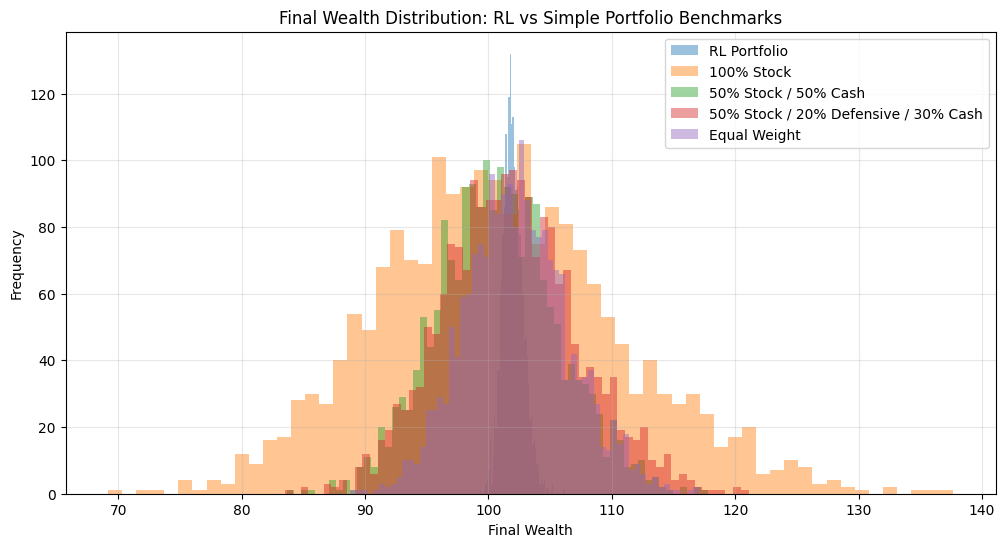

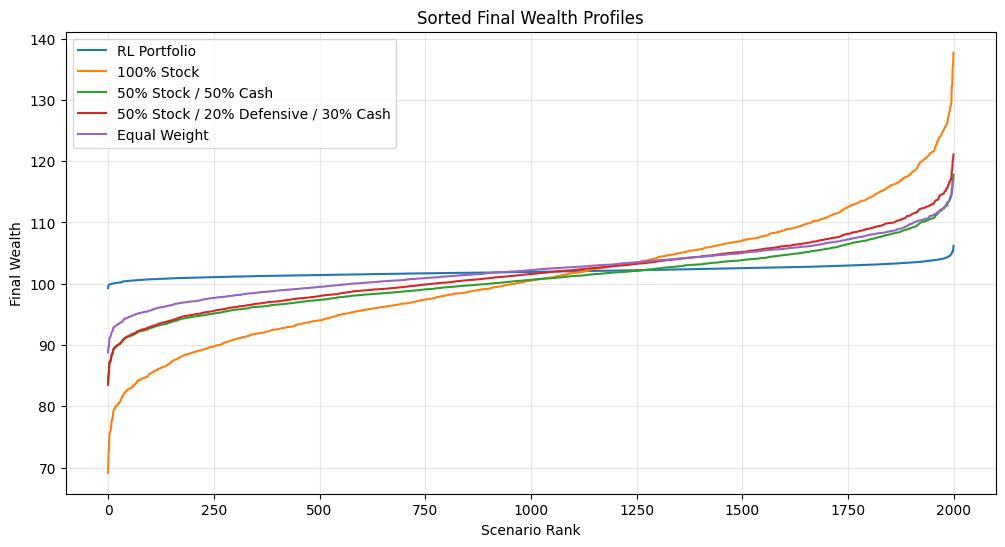

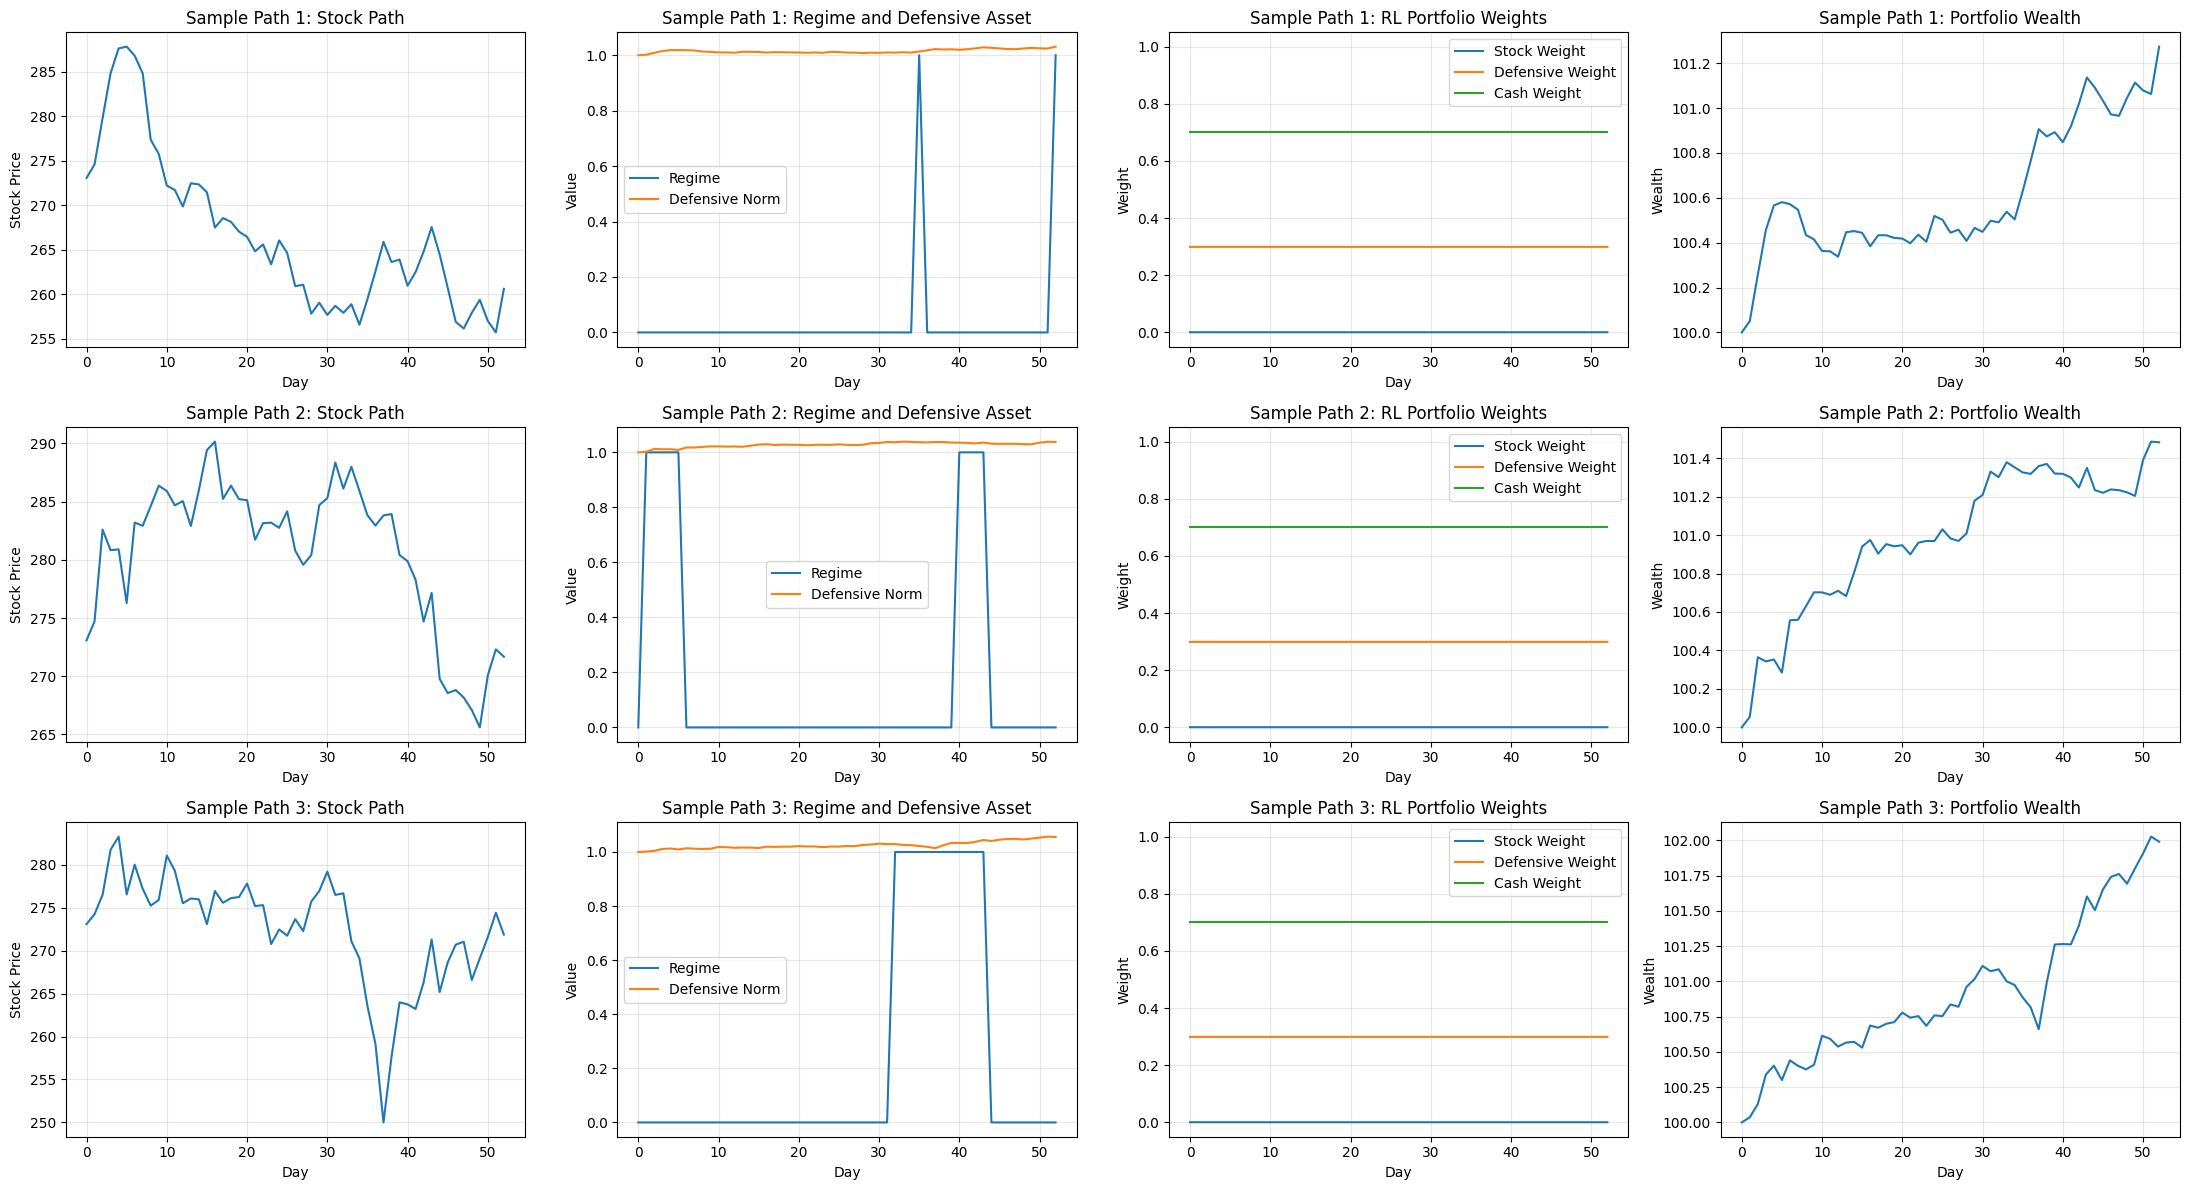

In [8]:
# ============================================================
# RL Portfolio Allocation with:
# - AAPL stock
# - defensive synthetic asset
# - cash
# - regime-dependent drift and volatility
# - richer state
# - excess-return reward
# ============================================================

# ============================================================
# 1. Inputs
# ============================================================

S0 = 273.08
T_days = 52
n_steps = T_days
dt = 1 / 365
r = 0.03686

transaction_cost_bps = 5
seed_train = 42
seed_test = 123

initial_wealth = 100.0

# Regime-dependent stock dynamics
mu_low = 0.12
mu_high = -0.08

sigma_low = 0.18
sigma_high = 0.40

# Reward / control
risk_penalty = 2.0
turnover_penalty = 0.03
weight_cap = 0.70


# ============================================================
# 2. Utility functions
# ============================================================

def capped_softmax_weights(x, cap=0.70):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    w = e / np.sum(e)

    for _ in range(10):
        over = w > cap
        if not np.any(over):
            break

        excess = np.sum(w[over] - cap)
        w[over] = cap

        under = ~over
        if np.sum(under) == 0:
            break

        total_under = np.sum(w[under])
        if total_under > 1e-12:
            w[under] += excess * (w[under] / total_under)
        else:
            w[under] = excess / np.sum(under)

    w = np.maximum(w, 0.0)
    w = w / np.sum(w)
    return w


def compute_drawdown(path, t):
    peak = np.max(path[:t+1])
    if peak <= 1e-12:
        return 0.0
    return path[t] / peak - 1.0


# ============================================================
# 3. Regime-switching simulation
# ============================================================

def simulate_regime_path(n_steps, p_stay_low=0.94, p_stay_high=0.88, seed=123):
    """
    Regime 0 = favorable regime (lower vol, positive drift)
    Regime 1 = stressed regime (higher vol, negative drift)
    """
    regimes = np.zeros(n_steps + 1, dtype=int)
    rng = np.random.default_rng(seed)
    regimes[0] = 0

    for t in range(1, n_steps + 1):
        prev = regimes[t - 1]
        u = rng.random()

        if prev == 0:
            regimes[t] = 0 if u < p_stay_low else 1
        else:
            regimes[t] = 1 if u < p_stay_high else 0

    return regimes


def simulate_stock_path_with_regimes(S0, mu_low, mu_high, sigma_low, sigma_high, regimes, dt, seed=123):
    rng = np.random.default_rng(seed)
    n_steps = len(regimes) - 1
    Z = rng.standard_normal(n_steps)

    path = np.zeros(n_steps + 1, dtype=float)
    path[0] = S0

    for t in range(1, n_steps + 1):
        if regimes[t - 1] == 0:
            mu_t = mu_low
            sigma_t = sigma_low
        else:
            mu_t = mu_high
            sigma_t = sigma_high

        path[t] = path[t - 1] * np.exp(
            (mu_t - 0.5 * sigma_t**2) * dt + sigma_t * np.sqrt(dt) * Z[t - 1]
        )

    return path


def build_defensive_asset_from_stock(stock_path):
    """
    Build a stable defensive synthetic asset from the same AAPL path.
    - participates partially on upside
    - loses much less on downside
    """
    n_steps = len(stock_path) - 1
    defensive = np.zeros(n_steps + 1, dtype=float)
    defensive[0] = 100.0

    for t in range(n_steps):
        stock_ret = stock_path[t + 1] / stock_path[t] - 1.0

        if stock_ret >= 0:
            def_ret = 0.35 * stock_ret
        else:
            def_ret = 0.15 * stock_ret

        defensive[t + 1] = defensive[t] * (1.0 + def_ret)

    return defensive


# ============================================================
# 4. RL environment
# ============================================================

class PortfolioEnv(gym.Env):
    """
    RL portfolio allocation across:
    - stock
    - defensive synthetic asset
    - cash

    State:
        [
            stock_norm,
            defensive_norm,
            tau_frac,
            ret_1,
            mom_5,
            mom_10,
            drawdown,
            regime_flag,
            stock_weight,
            defensive_weight,
            cash_weight
        ]
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        S0,
        r,
        mu_low,
        mu_high,
        sigma_low,
        sigma_high,
        n_steps,
        dt,
        transaction_cost_bps=5,
        initial_wealth=100.0,
        risk_penalty=2.0,
        turnover_penalty=0.03,
        weight_cap=0.70,
        seed=42
    ):
        super().__init__()

        self.S0 = float(S0)
        self.r = float(r)
        self.mu_low = float(mu_low)
        self.mu_high = float(mu_high)
        self.sigma_low = float(sigma_low)
        self.sigma_high = float(sigma_high)
        self.n_steps = int(n_steps)
        self.dt = float(dt)
        self.transaction_cost_bps = float(transaction_cost_bps)
        self.initial_wealth = float(initial_wealth)
        self.risk_penalty = float(risk_penalty)
        self.turnover_penalty = float(turnover_penalty)
        self.weight_cap = float(weight_cap)

        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Box(
            low=-5.0,
            high=5.0,
            shape=(3,),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([10.0, 10.0, 1.0, 1.0, 5.0, 5.0, 0.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.stock_path = None
        self.def_path = None
        self.regimes = None

        self.t = None
        self.wealth = None

        self.stock_units = None
        self.def_units = None
        self.cash = None

    def _simulate_paths(self):
        seed_regime = int(self.rng.integers(0, 1_000_000))
        seed_stock = int(self.rng.integers(0, 1_000_000))

        self.regimes = simulate_regime_path(
            n_steps=self.n_steps,
            p_stay_low=0.94,
            p_stay_high=0.88,
            seed=seed_regime
        )

        self.stock_path = simulate_stock_path_with_regimes(
            S0=self.S0,
            mu_low=self.mu_low,
            mu_high=self.mu_high,
            sigma_low=self.sigma_low,
            sigma_high=self.sigma_high,
            regimes=self.regimes,
            dt=self.dt,
            seed=seed_stock
        )

        self.def_path = build_defensive_asset_from_stock(self.stock_path)

    def _compute_weights(self, t):
        stock_value = self.stock_units * self.stock_path[t]
        def_value = self.def_units * self.def_path[t]
        cash_value = self.cash
        total = stock_value + def_value + cash_value

        if total <= 1e-12:
            return np.array([0.0, 0.0, 1.0])

        return np.array([
            stock_value / total,
            def_value / total,
            cash_value / total
        ])

    def _get_state(self):
        t = self.t

        stock_norm = self.stock_path[t] / self.S0
        def_norm = self.def_path[t] / self.def_path[0]
        tau_frac = (self.n_steps - t) / self.n_steps

        if t == 0:
            ret_1 = 0.0
            mom_5 = 0.0
            mom_10 = 0.0
        else:
            ret_1 = self.stock_path[t] / self.stock_path[t - 1] - 1.0
            t5 = max(0, t - 5)
            t10 = max(0, t - 10)
            mom_5 = self.stock_path[t] / self.stock_path[t5] - 1.0 if t5 < t else 0.0
            mom_10 = self.stock_path[t] / self.stock_path[t10] - 1.0 if t10 < t else 0.0

        drawdown = compute_drawdown(self.stock_path, t)
        w = self._compute_weights(t)

        state = np.array([
            stock_norm,
            def_norm,
            tau_frac,
            ret_1,
            mom_5,
            mom_10,
            drawdown,
            float(self.regimes[t]),
            w[0],
            w[1],
            w[2]
        ], dtype=np.float32)

        return state

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self._simulate_paths()

        self.t = 0
        self.wealth = self.initial_wealth

        self.stock_units = 0.0
        self.def_units = 0.0
        self.cash = self.initial_wealth

        return self._get_state(), {}

    def step(self, action):
        prev_wealth = (
            self.stock_units * self.stock_path[self.t]
            + self.def_units * self.def_path[self.t]
            + self.cash
        )
        prev_weights = self._compute_weights(self.t)

        target_weights = capped_softmax_weights(action, cap=self.weight_cap)

        stock_t = self.stock_path[self.t]
        def_t = self.def_path[self.t]

        target_stock_value = target_weights[0] * prev_wealth
        target_def_value = target_weights[1] * prev_wealth
        target_cash_value = target_weights[2] * prev_wealth

        target_stock_units = target_stock_value / stock_t
        target_def_units = target_def_value / def_t

        turnover_dollars = (
            abs(target_stock_units - self.stock_units) * stock_t
            + abs(target_def_units - self.def_units) * def_t
        )
        turnover_frac = turnover_dollars / max(prev_wealth, 1e-8)

        tc = turnover_dollars * (self.transaction_cost_bps / 10000.0)

        self.stock_units = target_stock_units
        self.def_units = target_def_units
        self.cash = max(target_cash_value - tc, 0.0)

        self.t += 1

        # accrue cash over step
        self.cash *= np.exp(self.r * self.dt)

        new_wealth = (
            self.stock_units * self.stock_path[self.t]
            + self.def_units * self.def_path[self.t]
            + self.cash
        )

        step_return = new_wealth / max(prev_wealth, 1e-8) - 1.0
        cash_step_return = np.exp(self.r * self.dt) - 1.0
        excess_return = step_return - cash_step_return

        reward = (
            excess_return
            - self.risk_penalty * (step_return ** 2)
            - self.turnover_penalty * turnover_frac
        )

        self.wealth = new_wealth

        terminated = self.t == self.n_steps
        truncated = False
        info = {"wealth": self.wealth}

        return self._get_state(), float(reward), terminated, truncated, info


# ============================================================
# 5. Train PPO
# ============================================================

def make_env():
    return PortfolioEnv(
        S0=S0,
        r=r,
        mu_low=mu_low,
        mu_high=mu_high,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        n_steps=n_steps,
        dt=dt,
        transaction_cost_bps=transaction_cost_bps,
        initial_wealth=initial_wealth,
        risk_penalty=risk_penalty,
        turnover_penalty=turnover_penalty,
        weight_cap=weight_cap,
        seed=seed_train
    )

vec_env = DummyVecEnv([make_env])

model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    verbose=1,
    learning_rate=1e-4,
    n_steps=1024,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.003
)

model.learn(total_timesteps=180000)


# ============================================================
# 6. Evaluation helpers
# ============================================================

def evaluate_rl_portfolio(model, n_eval_episodes=1000, seed=999):
    env = PortfolioEnv(
        S0=S0,
        r=r,
        mu_low=mu_low,
        mu_high=mu_high,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        n_steps=n_steps,
        dt=dt,
        transaction_cost_bps=transaction_cost_bps,
        initial_wealth=initial_wealth,
        risk_penalty=risk_penalty,
        turnover_penalty=turnover_penalty,
        weight_cap=weight_cap,
        seed=seed
    )

    final_wealths = []

    for _ in range(n_eval_episodes):
        obs, _ = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        final_wealths.append(info["wealth"])

    return np.array(final_wealths, dtype=float)


def run_fixed_weight_path(weights, seed=123):
    seed_regime = seed
    seed_stock = seed + 1000

    regimes = simulate_regime_path(n_steps=n_steps, seed=seed_regime)
    stock_path = simulate_stock_path_with_regimes(
        S0=S0,
        mu_low=mu_low,
        mu_high=mu_high,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        regimes=regimes,
        dt=dt,
        seed=seed_stock
    )
    def_path = build_defensive_asset_from_stock(stock_path)

    wealth = initial_wealth
    stock_units = 0.0
    def_units = 0.0
    cash = wealth
    weights = np.array(weights, dtype=float)

    for t in range(n_steps):
        stock_t = stock_path[t]
        def_t = def_path[t]

        target_stock_value = weights[0] * wealth
        target_def_value = weights[1] * wealth
        target_cash_value = weights[2] * wealth

        stock_units = target_stock_value / stock_t
        def_units = target_def_value / def_t
        cash = target_cash_value

        cash *= np.exp(r * dt)

        wealth = (
            stock_units * stock_path[t + 1]
            + def_units * def_path[t + 1]
            + cash
        )

    return wealth


def evaluate_fixed_weight_benchmark(weights, n_eval_paths=1000, seed=123):
    wealths = []
    for i in range(n_eval_paths):
        wealths.append(run_fixed_weight_path(weights, seed=seed + i))
    return np.array(wealths, dtype=float)


# ============================================================
# 7. Evaluate RL and benchmarks
# ============================================================

wealth_rl = evaluate_rl_portfolio(model, n_eval_episodes=2000, seed=seed_test + 100)

wealth_stock_only = evaluate_fixed_weight_benchmark([1.0, 0.0, 0.0], n_eval_paths=2000, seed=seed_test)
wealth_half_stock_cash = evaluate_fixed_weight_benchmark([0.5, 0.0, 0.5], n_eval_paths=2000, seed=seed_test)
wealth_stock_def_cash = evaluate_fixed_weight_benchmark([0.5, 0.2, 0.3], n_eval_paths=2000, seed=seed_test)
wealth_equal_weight = evaluate_fixed_weight_benchmark([1/3, 1/3, 1/3], n_eval_paths=2000, seed=seed_test)


# ============================================================
# 8. Summary table
# ============================================================

def summarize_wealth(name, wealth):
    returns = wealth / initial_wealth - 1.0
    return {
        "Strategy": name,
        "Mean Final Wealth": np.mean(wealth),
        "Median Final Wealth": np.median(wealth),
        "Std Final Wealth": np.std(wealth),
        "Mean Return": np.mean(returns),
        "1% Tail Wealth": np.percentile(wealth, 1),
        "5% Tail Wealth": np.percentile(wealth, 5),
        "Min Wealth": np.min(wealth),
        "Max Wealth": np.max(wealth)
    }

results = pd.DataFrame([
    summarize_wealth("RL Portfolio", wealth_rl),
    summarize_wealth("100% Stock", wealth_stock_only),
    summarize_wealth("50% Stock / 50% Cash", wealth_half_stock_cash),
    summarize_wealth("50% Stock / 20% Defensive / 30% Cash", wealth_stock_def_cash),
    summarize_wealth("Equal Weight", wealth_equal_weight)
])

print(results)


# ============================================================
# 9. Plots
# ============================================================

plt.figure(figsize=(12, 6))
plt.hist(wealth_rl, bins=60, alpha=0.45, label="RL Portfolio")
plt.hist(wealth_stock_only, bins=60, alpha=0.45, label="100% Stock")
plt.hist(wealth_half_stock_cash, bins=60, alpha=0.45, label="50% Stock / 50% Cash")
plt.hist(wealth_stock_def_cash, bins=60, alpha=0.45, label="50% Stock / 20% Defensive / 30% Cash")
plt.hist(wealth_equal_weight, bins=60, alpha=0.45, label="Equal Weight")
plt.title("Final Wealth Distribution: RL vs Simple Portfolio Benchmarks")
plt.xlabel("Final Wealth")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(np.sort(wealth_rl), label="RL Portfolio")
plt.plot(np.sort(wealth_stock_only), label="100% Stock")
plt.plot(np.sort(wealth_half_stock_cash), label="50% Stock / 50% Cash")
plt.plot(np.sort(wealth_stock_def_cash), label="50% Stock / 20% Defensive / 30% Cash")
plt.plot(np.sort(wealth_equal_weight), label="Equal Weight")
plt.title("Sorted Final Wealth Profiles")
plt.xlabel("Scenario Rank")
plt.ylabel("Final Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 10. Sample path diagnostics
# ============================================================

def get_rl_weight_path(model, seed=500):
    seed_regime = seed
    seed_stock = seed + 1000

    regimes = simulate_regime_path(n_steps=n_steps, seed=seed_regime)
    stock_path = simulate_stock_path_with_regimes(
        S0=S0,
        mu_low=mu_low,
        mu_high=mu_high,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        regimes=regimes,
        dt=dt,
        seed=seed_stock
    )
    def_path = build_defensive_asset_from_stock(stock_path)

    weights_hist = []
    wealth_hist = [initial_wealth]

    stock_units = 0.0
    def_units = 0.0
    cash = initial_wealth

    for t in range(n_steps + 1):
        wealth_t = stock_units * stock_path[t] + def_units * def_path[t] + cash
        wealth_t = max(wealth_t, 1e-8)

        stock_weight = (stock_units * stock_path[t]) / wealth_t
        def_weight = (def_units * def_path[t]) / wealth_t
        cash_weight = cash / wealth_t

        if t == 0:
            ret_1 = 0.0
            mom_5 = 0.0
            mom_10 = 0.0
        else:
            ret_1 = stock_path[t] / stock_path[t - 1] - 1.0
            t5 = max(0, t - 5)
            t10 = max(0, t - 10)
            mom_5 = stock_path[t] / stock_path[t5] - 1.0 if t5 < t else 0.0
            mom_10 = stock_path[t] / stock_path[t10] - 1.0 if t10 < t else 0.0

        drawdown = compute_drawdown(stock_path, t)
        tau_frac = (n_steps - t) / n_steps

        state = np.array([
            stock_path[t] / S0,
            def_path[t] / def_path[0],
            tau_frac,
            ret_1,
            mom_5,
            mom_10,
            drawdown,
            float(regimes[t]),
            stock_weight,
            def_weight,
            cash_weight
        ], dtype=np.float32)

        action, _ = model.predict(state, deterministic=True)
        target_weights = capped_softmax_weights(action, cap=weight_cap)
        weights_hist.append(target_weights.copy())

        if t < n_steps:
            target_stock_value = target_weights[0] * wealth_t
            target_def_value = target_weights[1] * wealth_t
            target_cash_value = target_weights[2] * wealth_t

            target_stock_units = target_stock_value / stock_path[t]
            target_def_units = target_def_value / def_path[t]

            turnover_dollars = (
                abs(target_stock_units - stock_units) * stock_path[t]
                + abs(target_def_units - def_units) * def_path[t]
            )
            tc = turnover_dollars * (transaction_cost_bps / 10000.0)

            stock_units = target_stock_units
            def_units = target_def_units
            cash = max(target_cash_value - tc, 0.0)
            cash *= np.exp(r * dt)

            wealth_next = (
                stock_units * stock_path[t + 1]
                + def_units * def_path[t + 1]
                + cash
            )
            wealth_hist.append(wealth_next)

    return stock_path, def_path, regimes, np.array(weights_hist), np.array(wealth_hist)


def plot_sample_portfolio_paths(model, n_sample_paths=3, base_seed=500):
    fig, axes = plt.subplots(n_sample_paths, 4, figsize=(22, 4 * n_sample_paths))
    if n_sample_paths == 1:
        axes = np.array([axes])

    for i in range(n_sample_paths):
        stock_path, def_path, regime_hist, weights_hist, wealth_hist = get_rl_weight_path(
            model=model,
            seed=base_seed + i
        )

        tgrid = np.arange(n_steps + 1)

        axes[i, 0].plot(tgrid, stock_path)
        axes[i, 0].set_title(f"Sample Path {i+1}: Stock Path")
        axes[i, 0].set_xlabel("Day")
        axes[i, 0].set_ylabel("Stock Price")
        axes[i, 0].grid(True, alpha=0.3)

        axes[i, 1].plot(tgrid, regime_hist, label="Regime")
        axes[i, 1].plot(tgrid, def_path / def_path[0], label="Defensive Norm")
        axes[i, 1].set_title(f"Sample Path {i+1}: Regime and Defensive Asset")
        axes[i, 1].set_xlabel("Day")
        axes[i, 1].set_ylabel("Value")
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()

        axes[i, 2].plot(tgrid, weights_hist[:, 0], label="Stock Weight")
        axes[i, 2].plot(tgrid, weights_hist[:, 1], label="Defensive Weight")
        axes[i, 2].plot(tgrid, weights_hist[:, 2], label="Cash Weight")
        axes[i, 2].set_title(f"Sample Path {i+1}: RL Portfolio Weights")
        axes[i, 2].set_xlabel("Day")
        axes[i, 2].set_ylabel("Weight")
        axes[i, 2].set_ylim(-0.05, 1.05)
        axes[i, 2].grid(True, alpha=0.3)
        axes[i, 2].legend()

        axes[i, 3].plot(tgrid, wealth_hist)
        axes[i, 3].set_title(f"Sample Path {i+1}: Portfolio Wealth")
        axes[i, 3].set_xlabel("Day")
        axes[i, 3].set_ylabel("Wealth")
        axes[i, 3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_sample_portfolio_paths(model, n_sample_paths=3, base_seed=500)